# Cross-Modal Overlap

This notebook compares shared GCC nodes and edges between the RNA and protein networks as the final cross-modal interpretation step in the network-analysis workflow.

## Inputs




- `RNA_CSD_GCC.txt` and `Protein_CSD_GCC.txt` from `network_and_gcc`


- GCC hub summaries from `topology_and_hubs`


- Module outputs from `modules`


- Optional GO summaries from `functional_enrichment`




## Outputs




- GCC node and edge overlap summaries


- RNA-protein module-overlap summary tables


- Shared-node hub annotation exports and optional Cytoscape-highlight outputs


- Permutation-test summaries for node and edge overlap




## Pipeline




1. Load the RNA and protein GCC exports and quantify shared nodes and edges.


2. Visualize the shared-node overlap and compare RNA and protein modules.


3. Annotate overlap genes with hub and dominant-edge context.


4. Compare degree and optional Cytoscape highlights for the overlap sets.


5. Run permutation-based node and edge overlap tests and save the summary outputs.




## Setup




The first code cell extends the import path to shared network-analysis helpers in `Pipeline/4_Network_Analysis/utils/network_and_gcc.py`, `Pipeline/4_Network_Analysis/utils/topology_and_hubs.py`, and `Pipeline/4_Network_Analysis/utils/modules_and_eigengenes.py`, plus local cross-modal helpers in `Pipeline/6_Cross_Modal_Comparison/utils/overlap.py`, then initializes the shared `AnalysisContext` and resolves the GCC inputs.

In [ ]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
NETWORK_ANALYSIS_DIR = NOTEBOOK_DIR.parent / "4_Network_Analysis"
CROSS_MODAL_UTILS_DIR = NOTEBOOK_DIR / "utils"
for search_path in [CROSS_MODAL_UTILS_DIR, NETWORK_ANALYSIS_DIR]:
    if str(search_path) not in sys.path:
        sys.path.insert(0, str(search_path))

import utils.network_and_gcc as notebook_utils
import utils.topology_and_hubs as topology_utils
import utils.modules_and_eigengenes as module_utils
import overlap as overlap_utils

notebook_utils = importlib.reload(notebook_utils)
topology_utils = importlib.reload(topology_utils)
module_utils = importlib.reload(module_utils)
overlap_utils = importlib.reload(overlap_utils)

from utils.network_and_gcc import (
    build_analysis_context,
    ensure_gcc_output,
    load_edges_clean,
 )
from utils.topology_and_hubs import (
    analyze_hub_homogeneity,
    find_top_hubs,
 )
from utils.modules_and_eigengenes import compute_module_overlap_matrices
from overlap import (
    allvalues_threshold_node_overlap_test,
    degree_preserving_edge_overlap_test,
    ensure_overlap_gcc_networks_in_cytoscape,
    load_allvalues_node_universe,
    mark_overlap_nodes_in_cytoscape,
 )

ctx = build_analysis_context(
    notebook_name="cross_modal_overlap",
    run_cytoscape=True,
    run_enrichment=False,
    save_figures=True,
 )
rna_gcc_path = ensure_gcc_output(
    ctx.network_files["rna_csd"],
    ctx.notebook_output_path("network_and_gcc", "RNA_CSD_GCC.txt"),
)
prot_gcc_path = ensure_gcc_output(
    ctx.network_files["prot_csd"],
    ctx.notebook_output_path("network_and_gcc", "Protein_CSD_GCC.txt"),
)

Using cached GCC export: C:\Users\tiril\Master-Tiril\results\notebooks\01_network_and_gcc\RNA_CSD_GCC.txt
Using cached GCC export: C:\Users\tiril\Master-Tiril\results\notebooks\01_network_and_gcc\Protein_CSD_GCC.txt


## Step 1: Quantify GCC node and edge overlap

This step uses `load_edges_clean` to load the GCC exports from `network_and_gcc` and computes the shared, RNA-only, and protein-only node and edge sets.

In [6]:
rna_gcc = load_edges_clean(rna_gcc_path)
prot_gcc = load_edges_clean(prot_gcc_path)

rna_nodes = set(rna_gcc['source']) | set(rna_gcc['target'])
prot_nodes = set(prot_gcc['source']) | set(prot_gcc['target'])

overlap = rna_nodes & prot_nodes
only_rna = rna_nodes - prot_nodes
only_protein = prot_nodes - rna_nodes


def build_undirected_edge_set(edges):
    return {
        tuple(sorted((source, target)))
        for source, target in edges[['source', 'target']].itertuples(index=False, name=None)
    }


rna_edges = build_undirected_edge_set(rna_gcc)
prot_edges = build_undirected_edge_set(prot_gcc)

edge_overlap = rna_edges & prot_edges
only_rna_edges = rna_edges - prot_edges
only_protein_edges = prot_edges - rna_edges

node_union_n = len(rna_nodes | prot_nodes)
edge_union_n = len(rna_edges | prot_edges)

print(f'RNA GCC nodes:      {len(rna_nodes)}')
print(f'Protein GCC nodes:  {len(prot_nodes)}')
print(f'Overlap:            {len(overlap)}')
print(f'Only in RNA:        {len(only_rna)}')
print(f'Only in Protein:    {len(only_protein)}')
print(f'Jaccard:            {len(overlap) / node_union_n:.4f}')

print()
print(f'RNA GCC edges:      {len(rna_edges)}')
print(f'Protein GCC edges:  {len(prot_edges)}')
print(f'Edge overlap:       {len(edge_overlap)}')
print(f'Only in RNA:        {len(only_rna_edges)}')
print(f'Only in Protein:    {len(only_protein_edges)}')
print(f'Edge Jaccard:       {len(edge_overlap) / edge_union_n:.4f}')

edge_overlap_summary = pd.DataFrame(
    {
        'Metric': ['RNA GCC edges', 'Protein GCC edges', 'Shared edges', 'RNA-only edges', 'Protein-only edges', 'Edge Jaccard'],
        'Value': [
            len(rna_edges),
            len(prot_edges),
            len(edge_overlap),
            len(only_rna_edges),
            len(only_protein_edges),
            round(len(edge_overlap) / edge_union_n, 4),
        ],
    }
)

display(edge_overlap_summary)

RNA GCC nodes:      1314
Protein GCC nodes:  1034
Overlap:            197
Only in RNA:        1117
Only in Protein:    837
Jaccard:            0.0916

RNA GCC edges:      3020
Protein GCC edges:  3353
Edge overlap:       2
Only in RNA:        3018
Only in Protein:    3351
Edge Jaccard:       0.0003


,Metric,Value
0,RNA GCC edges,3020.0000
1,Protein GCC edges,3353.0000
2,Shared edges,2.0000
3,RNA-only edges,3018.0000
4,Protein-only edges,3351.0000
5,Edge Jaccard,0.0003


## Step 2: Visualize GCC overlap

This step plots the shared-node overlap summaries and exports the core visual overview of the cross-modal GCC comparison.

Saved Venn diagram to C:\Users\tiril\Master-Tiril\results\notebooks\02a_overlap\GCC_overlap_venn.png


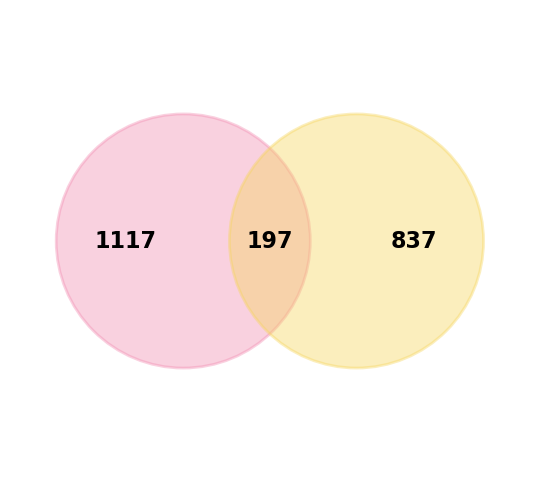

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

rna_only_n = len(only_rna)
overlap_n = len(overlap)
protein_only_n = len(only_protein)

fig, ax = plt.subplots(figsize=(8, 6))
left_center = (0.35, 0.5)
right_center = (0.65, 0.5)
radius = 0.22

ax.add_patch(Circle(left_center, radius, color="#F28CB1", alpha=0.4, lw=2))
ax.add_patch(Circle(right_center, radius, color="#F6D55C", alpha=0.4, lw=2))

ax.text(left_center[0] - 0.10, left_center[1], f"{rna_only_n}", ha="center", va="center", fontsize=16, fontweight="bold")
ax.text(0.5, 0.5, f"{overlap_n}", ha="center", va="center", fontsize=16, fontweight="bold")
ax.text(right_center[0] + 0.10, right_center[1], f"{protein_only_n}", ha="center", va="center", fontsize=16, fontweight="bold")

ax.set_xlim(0.05, 0.95)
ax.set_ylim(0.1, 0.9)
ax.set_aspect("equal")
ax.axis("off")

if ctx.save_figures:
    venn_path = ctx.output_path("GCC_overlap_venn.png")
    fig.savefig(venn_path, dpi=300, bbox_inches="tight")
    print(f"Saved Venn diagram to {venn_path}")

plt.show()

## Step 3: Compare RNA and protein modules

This step compares RNA and protein module assignments and writes the module-overlap summary table used later in interpretation and survival follow-up.

In [ ]:
rna_module_table = pd.read_csv(
    ctx.notebook_output_path('modules', 'RNA_Leiden_Modules_1.0', 'module_table.csv')
)
protein_module_table = pd.read_csv(
    ctx.notebook_output_path('modules', 'Protein_Leiden_Modules_1.0', 'module_table.csv')
)

_, _, module_overlap_summary = compute_module_overlap_matrices(
    rna_module_table,
    protein_module_table,
    label_a='RNA',
    label_b='Protein',
)

module_overlap_table = module_overlap_summary[[
    'rna_module',
    'protein_module',
    'overlap_genes',
    'overlap_count',
    'jaccard',
]]

display(module_overlap_table.head(10))

module_overlap_summary.to_csv(
    ctx.output_path('RNA_Protein_Module_Overlap_Summary.csv'),
    index=False,
 )

,rna_module,protein_module,overlap_genes,overlap_count,jaccard
0,7,4,"ASPN, CALD1, DCN, DPYSL3, FSTL1, HMCN1, LUM, M...",10,0.058480
1,5,4,"CD109, CEP170, LAMA4, MMP2, MSN, PCOLCE, PLS3,...",11,0.047210
2,3,2,"ALDH1L1, AP3D1, ASNS, CEL, CPPED1, CTRB2, CTRC...",19,0.039749
3,2,5,"CANX, GOLGB1, MAN2A1, NARS, PHKB, REEP5, RPL17...",14,0.031180
4,2,2,"ACAP2, COPB2, CRIP1, EIF4H, EIF5, GIGYF2, HSP9...",17,0.027778
5,2,1,"AK3, BIRC6, DCTN3, MAN1A2, NDUFS1, PLAC9, SPG1...",13,0.020800
6,4,1,"CHD4, DARS, LGALS1, LIMS1, MCFD2, NRP1, POSTN,...",9,0.020785
7,1,5,"DCTN4, LTN1, RAB1A, RHOT1, SEC62, SPCS3, STT3B...",8,0.017505
8,1,1,"ADAM9, AIDA, DPP7, ERBIN, NAA25, PPIP5K2, RICT...",11,0.017488
9,4,2,"BCAT1, CHGB, CLIC1, HLA-DRA, INA, ITIH3, PPIB",7,0.016432


## Step 4: Annotate shared nodes with hub context

This step uses `find_top_hubs` to flag shared genes whose GCC degree is high in the RNA or protein network and exports the dominant edge-type annotations for each overlap gene.

In [4]:
HUB_MIN_DEGREE = 50

rna_hubs = find_top_hubs(rna_gcc, min_degree=HUB_MIN_DEGREE)
prot_hubs = find_top_hubs(prot_gcc, min_degree=HUB_MIN_DEGREE)

rna_hub_set = {gene for gene, _ in rna_hubs}
prot_hub_set = {gene for gene, _ in prot_hubs}

rna_homogeneity = pd.DataFrame(analyze_hub_homogeneity(rna_gcc, sorted(overlap)))
prot_homogeneity = pd.DataFrame(analyze_hub_homogeneity(prot_gcc, sorted(overlap)))

rna_degree = pd.concat([rna_gcc["source"], rna_gcc["target"]]).value_counts()
prot_degree = pd.concat([prot_gcc["source"], prot_gcc["target"]]).value_counts()


def classify_csd_agreement(row):
    rna_type = row["DominantType_RNA"]
    protein_type = row["DominantType_Protein"]

    if pd.isna(rna_type) or pd.isna(protein_type):
        return "Missing dominant type"
    if rna_type == protein_type:
        return f"Congruent {rna_type}"
    return "Discordant"


overlap_summary = (
    pd.DataFrame({"Gene": sorted(overlap)})
    .assign(
        Shared_GCC_Node=True,
        CytoscapeLabel=lambda df: df["Gene"],
        Degree_RNA=lambda df: df["Gene"].map(rna_degree).fillna(0).astype(int),
        Degree_Protein=lambda df: df["Gene"].map(prot_degree).fillna(0).astype(int),
        Hub_RNA=lambda df: df["Gene"].isin(rna_hub_set),
        Hub_Protein=lambda df: df["Gene"].isin(prot_hub_set),
    )
    .merge(
        rna_homogeneity[["Hub", "dominant_type", "homogeneity_score"]].rename(
            columns={
                "Hub": "Gene",
                "dominant_type": "DominantType_RNA",
                "homogeneity_score": "HomogeneityScore_RNA",
            }
        ),
        on="Gene",
        how="left",
    )
    .merge(
        prot_homogeneity[["Hub", "dominant_type", "homogeneity_score"]].rename(
            columns={
                "Hub": "Gene",
                "dominant_type": "DominantType_Protein",
                "homogeneity_score": "HomogeneityScore_Protein",
            }
        ),
        on="Gene",
        how="left",
    )
    .assign(
        CSD_Agreement=lambda df: df.apply(classify_csd_agreement, axis=1),
    )
    .sort_values(["Degree_RNA", "Degree_Protein", "Gene"], ascending=[False, False, True])
    .reset_index(drop=True)
)

assert len(overlap_summary) == len(overlap)

output_file = ctx.output_path("GCC_overlap_node_annotations.csv")
overlap_summary.to_csv(output_file, index=False)

subset_files = {
    "Congruent C": ctx.output_path("GCC_overlap_concordant_c_nodes.csv"),
    "Congruent S": ctx.output_path("GCC_overlap_concordant_s_nodes.csv"),
    "Congruent D": ctx.output_path("GCC_overlap_concordant_d_nodes.csv"),
    "Discordant": ctx.output_path("GCC_overlap_discordant_nodes.csv"),
}

saved_subset_total = 0
for agreement_label, subset_path in subset_files.items():
    subset_df = overlap_summary.loc[overlap_summary["CSD_Agreement"] == agreement_label].copy()
    subset_df.to_csv(subset_path, index=False)
    saved_subset_total += len(subset_df)
    print(f"Saved {len(subset_df)} nodes with '{agreement_label}' to {subset_path}")

assert saved_subset_total == len(
    overlap_summary.loc[overlap_summary["CSD_Agreement"].isin(subset_files)]
)

print(f"Saved {len(overlap_summary)} overlap nodes to {output_file}")
print(f"RNA hub threshold: degree > {HUB_MIN_DEGREE} ({len(rna_hub_set)} genes)")
print(f"Protein hub threshold: degree > {HUB_MIN_DEGREE} ({len(prot_hub_set)} genes)")
display(overlap_summary.head(20))
display(overlap_summary[["Hub_RNA", "Hub_Protein"]].sum().rename("n").to_frame())
display(overlap_summary[["HomogeneityScore_RNA", "HomogeneityScore_Protein"]].describe().T)
display(overlap_summary["CSD_Agreement"].value_counts(dropna=False).rename_axis("CSD_Agreement").to_frame("n"))

Saved 32 nodes with 'Congruent C' to C:\Users\tiril\Master-Tiril\results\notebooks\02a_overlap\GCC_overlap_concordant_c_nodes.csv
Saved 21 nodes with 'Congruent S' to C:\Users\tiril\Master-Tiril\results\notebooks\02a_overlap\GCC_overlap_concordant_s_nodes.csv
Saved 35 nodes with 'Congruent D' to C:\Users\tiril\Master-Tiril\results\notebooks\02a_overlap\GCC_overlap_concordant_d_nodes.csv
Saved 109 nodes with 'Discordant' to C:\Users\tiril\Master-Tiril\results\notebooks\02a_overlap\GCC_overlap_discordant_nodes.csv
Saved 197 overlap nodes to C:\Users\tiril\Master-Tiril\results\notebooks\02a_overlap\GCC_overlap_node_annotations.csv
RNA hub threshold: degree > 50 (14 genes)
Protein hub threshold: degree > 50 (23 genes)


,Gene,Shared_GCC_Node,CytoscapeLabel,Degree_RNA,Degree_Protein,Hub_RNA,Hub_Protein,DominantType_RNA,HomogeneityScore_RNA,DominantType_Protein,HomogeneityScore_Protein,CSD_Agreement
0,SEPT7,True,SEPT7,383,55,True,True,D,0.9112,D,0.9273,Congruent D
1,CTRB2,True,CTRB2,49,1,False,False,S,1.0000,S,1.0000,Congruent S
2,SPTBN2,True,SPTBN2,37,2,False,False,S,1.0000,S,1.0000,Congruent S
3,ERP27,True,ERP27,33,8,False,False,S,1.0000,S,1.0000,Congruent S
4,BCAP29,True,BCAP29,32,2,False,False,C,0.9688,C,0.5000,Congruent C
5,PPFIBP1,True,PPFIBP1,27,4,False,False,D,1.0000,C,1.0000,Discordant
6,RAI14,True,RAI14,24,3,False,False,D,1.0000,C,1.0000,Discordant
7,SEC31A,True,SEC31A,22,8,False,False,D,1.0000,D,1.0000,Congruent D
8,FNDC3B,True,FNDC3B,21,3,False,False,D,1.0000,D,0.6667,Congruent D
9,NES,True,NES,21,1,False,False,S,1.0000,C,1.0000,Discordant


,n
Hub_RNA,1
Hub_Protein,11


,count,mean,std,min,25%,50%,75%,max
HomogeneityScore_RNA,197.0,0.936382,0.151835,0.3333,1.0,1.0,1.0,1.0
HomogeneityScore_Protein,197.0,0.949725,0.126223,0.5000,1.0,1.0,1.0,1.0


,n
CSD_Agreement,
Discordant,109
Congruent D,35
Congruent C,32
Congruent S,21


## Step 5: Inspect hub overlap

This step summarizes the shared-node overlap through the lens of the RNA and protein GCC hub sets.

In [5]:
shared_hubs = sorted(rna_hub_set & prot_hub_set)
rna_only_hubs = sorted(rna_hub_set - prot_hub_set)
prot_only_hubs = sorted(prot_hub_set - rna_hub_set)

hub_overlap_summary = pd.DataFrame(
    {
        "Category": ["Shared hubs", "RNA-only hubs", "Protein-only hubs"],
        "Count": [len(shared_hubs), len(rna_only_hubs), len(prot_only_hubs)],
        "Genes": [
            ", ".join(shared_hubs) if shared_hubs else "-",
            ", ".join(rna_only_hubs) if rna_only_hubs else "-",
            ", ".join(prot_only_hubs) if prot_only_hubs else "-",
        ],
    }
)

print(f"RNA hubs (top {len(rna_hub_set)}): {len(rna_hub_set)}")
print(f"Protein hubs (top {len(prot_hub_set)}): {len(prot_hub_set)}")
print(f"Shared hubs: {len(shared_hubs)}")

display(hub_overlap_summary)

if shared_hubs:
    shared_hub_degrees = (
        overlap_summary.loc[overlap_summary["Gene"].isin(shared_hubs), ["Gene", "Degree_RNA", "Degree_Protein", "CSD_Agreement"]]
        .sort_values(["Degree_RNA", "Degree_Protein", "Gene"], ascending=[False, False, True])
        .reset_index(drop=True)
    )
    display(shared_hub_degrees)
else:
    print("No shared hubs between the RNA and protein top-hub sets.")

RNA hubs (top 14): 14
Protein hubs (top 23): 23
Shared hubs: 1


,Category,Count,Genes
0,Shared hubs,1,SEPT7
1,RNA-only hubs,13,"ANKRD54, AQP8, CBX3, CREB1, CUL4B, IGFBP2, MAT..."
2,Protein-only hubs,22,"CANX, DPYSL2, DPYSL3, EHBP1L1, EML4, GSN, IFI1..."


,Gene,Degree_RNA,Degree_Protein,CSD_Agreement
0,SEPT7,383,55,Congruent D


## Step 6: Compare RNA and protein degree

This step compares node degree across the shared GCC genes to highlight whether overlap nodes are similarly connected in the two modalities.

Saved scatter plot to C:\Users\tiril\Master-Tiril\results\notebooks\02a_overlap\GCC_overlap_degree_scatter.png


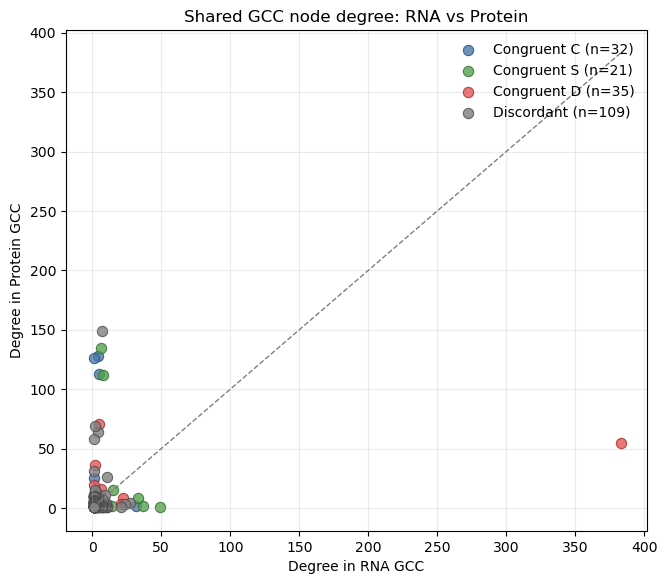

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))

group_order = ["Congruent C", "Congruent S", "Congruent D", "Discordant", "Missing dominant type"]
group_colors = {
    "Congruent C": "#4C78A8",
    "Congruent S": "#54A24B",
    "Congruent D": "#E45756",
    "Discordant": "#7F7F7F",
    "Missing dominant type": "#D9D9D9",
}
group_edges = {
    "Congruent C": "#1F4E79",
    "Congruent S": "#2F6B2F",
    "Congruent D": "#9E2A2B",
    "Discordant": "#4D4D4D",
    "Missing dominant type": "#8C8C8C",
}

for group in group_order:
    subset = overlap_summary.loc[overlap_summary["CSD_Agreement"] == group]
    if subset.empty:
        continue
    ax.scatter(
        subset["Degree_RNA"],
        subset["Degree_Protein"],
        s=55,
        color=group_colors[group],
        edgecolor=group_edges[group],
        linewidth=0.8,
        alpha=0.8,
        label=f"{group} (n={len(subset)})",
    )

max_degree = max(
    overlap_summary["Degree_RNA"].max(),
    overlap_summary["Degree_Protein"].max(),
)
ax.plot([0, max_degree], [0, max_degree], linestyle="--", color="#7F7F7F", linewidth=1)

ax.set_xlabel("Degree in RNA GCC")
ax.set_ylabel("Degree in Protein GCC")
ax.set_title("Shared GCC node degree: RNA vs Protein")
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="upper right")

if ctx.save_figures:
    scatter_path = ctx.output_path("GCC_overlap_degree_scatter.png")
    fig.savefig(scatter_path, dpi=300, bbox_inches="tight")
    print(f"Saved scatter plot to {scatter_path}")

plt.show()

## Step 7: Optional Cytoscape highlighting

This step exports or applies Cytoscape highlighting for the overlap-driven gene subsets when Cytoscape support is enabled.

In [8]:
if ctx.run_cytoscape:
    cytoscape_networks = ensure_overlap_gcc_networks_in_cytoscape(
        ctx.network_files['rna_csd'],
        ctx.network_files['prot_csd'],
        collection='CSD',
    )
    display(cytoscape_networks)

    mark_overlap_nodes_in_cytoscape(
        ['RNA_CSD_GCC', 'Protein_CSD_GCC'],
        overlap,
        color='#E36209',
        size=45,
    )
else:
    print('Skipping Cytoscape overlap annotation: ctx.run_cytoscape=False')

You are connected to Cytoscape!


,network,kind,status,suid,parent_network
0,RNA_CSD,full_network,reused,<NA>,<NA>
1,RNA_CSD_GCC,gcc_subnetwork,reused,<NA>,RNA_CSD
2,Protein_CSD,full_network,reused,<NA>,<NA>
3,Protein_CSD_GCC,gcc_subnetwork,reused,<NA>,Protein_CSD


You are connected to Cytoscape!
Marked 199 overlap nodes in 'RNA_CSD_GCC'.
Marked 199 overlap nodes in 'Protein_CSD_GCC'.


## Step 8: Permutation test

This step runs the node and edge overlap permutation procedures and saves the corresponding significance summaries.

In [ ]:
rna_csd = load_edges_clean(ctx.network_files["rna_csd"])
prot_csd = load_edges_clean(ctx.network_files["prot_csd"])

rna_allvalues_nodes = load_allvalues_node_universe(
    ctx.project_root / "results" / "networks" / "AllValues_rna_cptac_wTO.txt"
)
prot_allvalues_nodes = load_allvalues_node_universe(
    ctx.project_root / "results" / "networks" / "AllValues_proteome_cptac_wTO.txt"
)
shared_allvalues_nodes = rna_allvalues_nodes & prot_allvalues_nodes

node_overlap_result = allvalues_threshold_node_overlap_test(
    rna_selected_edges=rna_csd,
    protein_selected_edges=prot_csd,
    rna_allvalues_nodes=rna_allvalues_nodes,
    protein_allvalues_nodes=prot_allvalues_nodes,
    n_perm=10_000,
    seed=42,
)
edge_overlap_result = degree_preserving_edge_overlap_test(
    reference_edges=rna_csd,
    randomized_edges=prot_csd,
    allowed_nodes=shared_allvalues_nodes,
    n_perm=1_000,
    nswap_multiplier=5,
    seed=42,
)

node_overlap_summary = pd.DataFrame(
    [{k: v for k, v in node_overlap_result.items() if k != "null_overlaps"}]
)
edge_overlap_permutation_summary = pd.DataFrame(
    [{k: v for k, v in edge_overlap_result.items() if k != "null_overlaps"}]
)

node_overlap_summary.to_csv(ctx.output_path("AllValues_threshold_node_overlap_permutation_summary.csv"), index=False)
edge_overlap_permutation_summary.to_csv(ctx.output_path("AllValues_threshold_edge_overlap_permutation_summary.csv"), index=False)
pd.DataFrame({"null_overlap": node_overlap_result["null_overlaps"]}).to_csv(
    ctx.output_path("AllValues_threshold_node_overlap_null.csv"), index=False
)
pd.DataFrame({"null_overlap": edge_overlap_result["null_overlaps"]}).to_csv(
    ctx.output_path("AllValues_threshold_edge_overlap_null.csv"), index=False
)

print("Node overlap permutation test")
display(node_overlap_summary)
print("Edge overlap permutation test")
display(edge_overlap_permutation_summary)


Node overlap permutation test


,observed_overlap,expected_overlap_mean,expected_overlap_sd,p_enrichment,p_depletion,p_two_sided,exact_p_enrichment,exact_p_depletion,exact_p_two_sided,exact_expected_overlap,n_permutations,rna_selected_edges,protein_selected_edges,rna_selected_nodes,protein_selected_nodes,rna_selected_nodes_outside_shared_universe,protein_selected_nodes_outside_shared_universe,rna_allvalues_nodes,protein_allvalues_nodes,shared_allvalues_nodes
0,227,181.7682,11.599333,0.0003,0.9998,0.0006,0.000072,0.999949,0.000144,181.779281,10000,3093,3370,1459,1068,0,0,8572,8572,8572


Edge overlap permutation test


,observed_overlap,expected_overlap_mean,expected_overlap_sd,p_enrichment,p_depletion,p_two_sided,n_permutations,failed_permutations,attempts,nswap,max_tries,reference_edges,randomized_edges,reference_nodes,randomized_nodes,background_node_count
0,2,5.32,1.796894,0.987013,0.051948,0.103896,1000,0,1000,16850,337000,3093,3370,1459,1068,8572
